In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
#dropping columns
df.drop(['Churn Label','Churn Score','CLTV','Churn Reason'], axis=1, inplace= True) # axis=0 -> to remove rows, axis=1 -> to remove columns
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [5]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [6]:
# Loop through each column in the DataFrame
for col in df.columns:
    # Check the number of unique values in the column
    if df[col].nunique() < 2:
         # If the column has less than 2 unique values, drop it from the DataFrame
        df.drop(col, axis=1, inplace=True)

In [7]:
df.head()

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [8]:
#removing customer ID and Lat Long because it is unnecessary
df.drop(['CustomerID','Lat Long'], axis=1, inplace= True)
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [9]:
df.columns=df.columns.str.replace("-","_")

In [10]:
df['City']=df['City'].replace(" ","_", regex=True)

In [11]:
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [12]:
df.dtypes

City                  object
Zip Code               int64
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Value            int64
dtype: object

In [13]:
# Loop through each column in the DataFrame
for col in df.columns:
    # Check if the column's data type is 'object' (i.e., string/categorical)
    if df[col].dtype == 'object':
        # Print the column name
        print(f"\nColumn: {col}")
        
        # Print the unique values in that column
        print(df[col].unique())


Column: City
['Los_Angeles' 'Beverly_Hills' 'Huntington_Park' ... 'Standish' 'Tulelake'
 'Olympic_Valley']

Column: Gender
['Male' 'Female']

Column: Senior Citizen
['No' 'Yes']

Column: Partner
['No' 'Yes']

Column: Dependents
['No' 'Yes']

Column: Phone Service
['Yes' 'No']

Column: Multiple Lines
['No' 'Yes' 'No phone service']

Column: Internet Service
['DSL' 'Fiber optic' 'No']

Column: Online Security
['Yes' 'No' 'No internet service']

Column: Online Backup
['Yes' 'No' 'No internet service']

Column: Device Protection
['No' 'Yes' 'No internet service']

Column: Tech Support
['No' 'Yes' 'No internet service']

Column: Streaming TV
['No' 'Yes' 'No internet service']

Column: Streaming Movies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'Two year' 'One year']

Column: Paperless Billing
['Yes' 'No']

Column: Payment Method
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: Total Charges
[108.15 151.65 820.5 

In [14]:
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [15]:
#Handling missing values, converted spaces into 0
df.loc[(df['Total Charges']==' '),'Total Charges']=0

In [16]:
df['Total Charges']=pd.to_numeric(df['Total Charges'])

In [17]:
df['Total Charges'].dtype

dtype('float64')

In [18]:
for col in df.columns:
    new_col = col.replace(' ', '_')
    df.rename(columns={col: new_col}, inplace=True)

In [19]:
#fill spaces in col values into _
df.replace(" ","_",regex=True, inplace=True)

In [20]:
df.head()

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed_check,53.85,108.15,1
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic_check,70.70,151.65,1
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic_check,99.65,820.50,1
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic_check,104.80,3046.05,1
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank_transfer_(automatic),103.70,5036.30,1


In [21]:
# Loop through each column in the DataFrame
for col in df.columns:
    # Check if the column's data type is 'object' (i.e., string/categorical)
    if df[col].dtype == 'object':
        # Print the column name
        print(f"\nColumn: {col}")
        
        # Print the unique values in that column
        print(df[col].unique())


Column: City
['Los_Angeles' 'Beverly_Hills' 'Huntington_Park' ... 'Standish' 'Tulelake'
 'Olympic_Valley']

Column: Gender
['Male' 'Female']

Column: Senior_Citizen
['No' 'Yes']

Column: Partner
['No' 'Yes']

Column: Dependents
['No' 'Yes']

Column: Phone_Service
['Yes' 'No']

Column: Multiple_Lines
['No' 'Yes' 'No_phone_service']

Column: Internet_Service
['DSL' 'Fiber_optic' 'No']

Column: Online_Security
['Yes' 'No' 'No_internet_service']

Column: Online_Backup
['Yes' 'No' 'No_internet_service']

Column: Device_Protection
['No' 'Yes' 'No_internet_service']

Column: Tech_Support
['No' 'Yes' 'No_internet_service']

Column: Streaming_TV
['No' 'Yes' 'No_internet_service']

Column: Streaming_Movies
['No' 'Yes' 'No_internet_service']

Column: Contract
['Month-to-month' 'Two_year' 'One_year']

Column: Paperless_Billing
['Yes' 'No']

Column: Payment_Method
['Mailed_check' 'Electronic_check' 'Bank_transfer_(automatic)'
 'Credit_card_(automatic)']


In [22]:
#df['Churn_Value']==0 (people who left)
#df['Churn_Value']==0 (people who remained)

# Define your features (X) and target (y)
X = df.drop('Churn_Value', axis=1)   # All columns except 'Churn Value'
y = df['Churn_Value']                # Target column

In [23]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [24]:
X_encoded.head()

,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,City_Acton,City_Adelanto,City_Adin,City_Agoura_Hills,...,Streaming_TV_No_internet_service,Streaming_TV_Yes,Streaming_Movies_No_internet_service,Streaming_Movies_Yes,Contract_One_year,Contract_Two_year,Paperless_Billing_Yes,Payment_Method_Credit_card_(automatic),Payment_Method_Electronic_check,Payment_Method_Mailed_check
0,90003,33.964131,-118.272783,2,53.85,108.15,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,34.059281,-118.307420,2,70.70,151.65,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,34.048013,-118.293953,8,99.65,820.50,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,90010,34.062125,-118.315709,28,104.80,3046.05,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,90015,34.039224,-118.266293,49,103.70,5036.30,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [25]:
# Convert any boolean columns to integers (0 and 1)
X_encoded = X_encoded.astype(int)

In [26]:
X_encoded.head()

,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,City_Acton,City_Adelanto,City_Adin,City_Agoura_Hills,...,Streaming_TV_No_internet_service,Streaming_TV_Yes,Streaming_Movies_No_internet_service,Streaming_Movies_Yes,Contract_One_year,Contract_Two_year,Paperless_Billing_Yes,Payment_Method_Credit_card_(automatic),Payment_Method_Electronic_check,Payment_Method_Mailed_check
0,90003,33,-118,2,53,108,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,90005,34,-118,2,70,151,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,90006,34,-118,8,99,820,0,0,0,0,...,0,1,0,1,0,0,1,0,1,0
3,90010,34,-118,28,104,3046,0,0,0,0,...,0,1,0,1,0,0,1,0,1,0
4,90015,34,-118,49,103,5036,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, random_state=42, stratify=y
)

In [28]:
# Check the class distribution in train vs test
print("Train set churn distribution:\n", y_train.value_counts(normalize=True))
print("\nTest set churn distribution:\n", y_test.value_counts(normalize=True))

Train set churn distribution:
 Churn_Value
0    0.73457
1    0.26543
Name: proportion, dtype: float64

Test set churn distribution:
 Churn_Value
0    0.73481
1    0.26519
Name: proportion, dtype: float64


In [29]:
!pip install --upgrade xgboost


In [30]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='aucpr',# set here instead of fit()
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-aucpr:0.63059
[1]	validation_0-aucpr:0.64619
[2]	validation_0-aucpr:0.64575
[3]	validation_0-aucpr:0.65441
[4]	validation_0-aucpr:0.65290
[5]	validation_0-aucpr:0.65268
[6]	validation_0-aucpr:0.64989
[7]	validation_0-aucpr:0.65083
[8]	validation_0-aucpr:0.65296
[9]	validation_0-aucpr:0.65458
[10]	validation_0-aucpr:0.65439
[11]	validation_0-aucpr:0.65569
[12]	validation_0-aucpr:0.65690
[13]	validation_0-aucpr:0.65751
[14]	validation_0-aucpr:0.66079
[15]	validation_0-aucpr:0.66035
[16]	validation_0-aucpr:0.65939
[17]	validation_0-aucpr:0.65935
[18]	validation_0-aucpr:0.66062
[19]	validation_0-aucpr:0.65950
[20]	validation_0-aucpr:0.65899
[21]	validation_0-aucpr:0.65827
[22]	validation_0-aucpr:0.65786
[23]	validation_0-aucpr:0.65818
[24]	validation_0-aucpr:0.65860
[25]	validation_0-aucpr:0.65819
[26]	validation_0-aucpr:0.65825
[27]	validation_0-aucpr:0.65932
[28]	validation_0-aucpr:0.65614
[29]	validation_0-aucpr:0.65660
[30]	validation_0-aucpr:0.65590
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

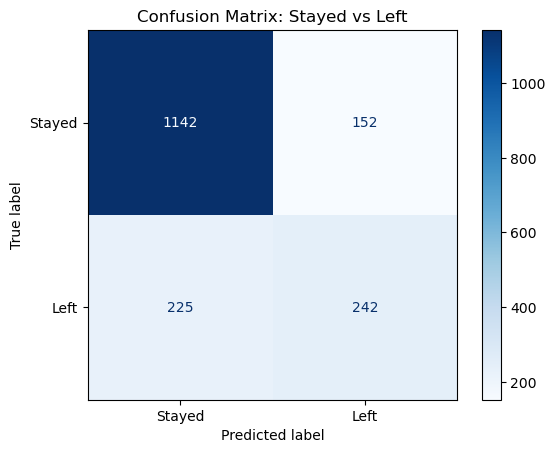

In [31]:
# Predict on test set
y_pred = xgb_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define custom labels: first = Stayed (0), second = Left (1)
labels = ['Stayed', 'Left']

# Plot confusion matrix with custom labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Stayed vs Left")
plt.show()


In [32]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.7859170925610448

📊 Confusion Matrix:
 [[1142  152]
 [ 225  242]]

📈 Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1294
           1       0.61      0.52      0.56       467

    accuracy                           0.79      1761
   macro avg       0.72      0.70      0.71      1761
weighted avg       0.78      0.79      0.78      1761



In [33]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid
param_grid = {
    'max_depth': [3, 4, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.25],
    'gamma': [0, 0.1, 0.3, 0.25],
    'reg_lambda': [1, 1.5, 2,10],
    'scale_pos_weight': [1, 2, 5, 10]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_encoded, y)

print("✅ Best Parameters:\n", random_search.best_params_)
best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Best Parameters:
 {'scale_pos_weight': 1, 'reg_lambda': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0}


[0]	validation_0-aucpr:0.48592
[1]	validation_0-aucpr:0.58198
[2]	validation_0-aucpr:0.59149
[3]	validation_0-aucpr:0.59415
[4]	validation_0-aucpr:0.60161
[5]	validation_0-aucpr:0.60436
[6]	validation_0-aucpr:0.61501
[7]	validation_0-aucpr:0.61911
[8]	validation_0-aucpr:0.62456
[9]	validation_0-aucpr:0.62495
[10]	validation_0-aucpr:0.62323
[11]	validation_0-aucpr:0.62530
[12]	validation_0-aucpr:0.62690
[13]	validation_0-aucpr:0.62743
[14]	validation_0-aucpr:0.63645
[15]	validation_0-aucpr:0.63820
[16]	validation_0-aucpr:0.63889
[17]	validation_0-aucpr:0.64011
[18]	validation_0-aucpr:0.64331


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:30:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "cv" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[19]	validation_0-aucpr:0.64313
[20]	validation_0-aucpr:0.64790
[21]	validation_0-aucpr:0.64574
[22]	validation_0-aucpr:0.64438
[23]	validation_0-aucpr:0.64483
[24]	validation_0-aucpr:0.64477
[25]	validation_0-aucpr:0.64481
[26]	validation_0-aucpr:0.64559
[27]	validation_0-aucpr:0.64517
[28]	validation_0-aucpr:0.64594
[29]	validation_0-aucpr:0.64591
[30]	validation_0-aucpr:0.64583
[31]	validation_0-aucpr:0.64575
[32]	validation_0-aucpr:0.64643
[33]	validation_0-aucpr:0.65139
[34]	validation_0-aucpr:0.65152
[35]	validation_0-aucpr:0.64833
[36]	validation_0-aucpr:0.64828
[37]	validation_0-aucpr:0.64755
[38]	validation_0-aucpr:0.64939
[39]	validation_0-aucpr:0.65268
[40]	validation_0-aucpr:0.64933
[41]	validation_0-aucpr:0.65328
[42]	validation_0-aucpr:0.65289
[43]	validation_0-aucpr:0.65714
[44]	validation_0-aucpr:0.65673
[45]	validation_0-aucpr:0.65670
[46]	validation_0-aucpr:0.65723
[47]	validation_0-aucpr:0.65740
[48]	validation_0-aucpr:0.65734
[49]	validation_0-aucpr:0.65695
[50]	val

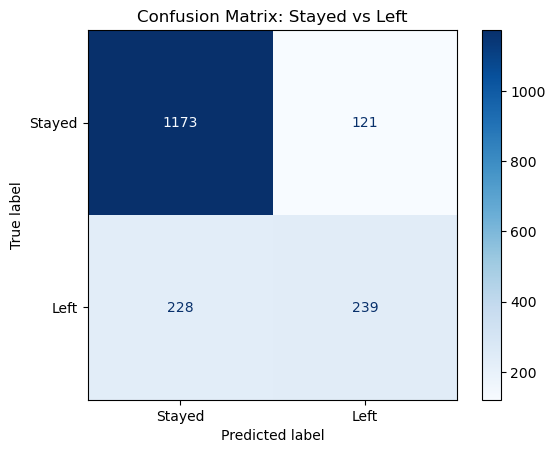

✅ Accuracy: 0.8018171493469619

📈 Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1294
           1       0.66      0.51      0.58       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761



In [34]:

# Retrain XGBoost with best hyperparameters
best_model = XGBClassifier(seed=42,
    objective='binary:logistic',
    eval_metric='aucpr',
    max_depth=3,
    learning_rate=0.05,
    gamma=0,
    reg_lambda=10,
    subsample=0.9,
    colsample_bytree=0.5,
    scale_pos_weight=1,
    cv=3
)

# Fit on the original training data
best_model.fit(X_train, y_train, verbose=True, eval_set=[(X_test, y_test)],)  # no early stopping

# Predict on test set
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed','Left'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Stayed vs Left")
plt.show()

# Metrics
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

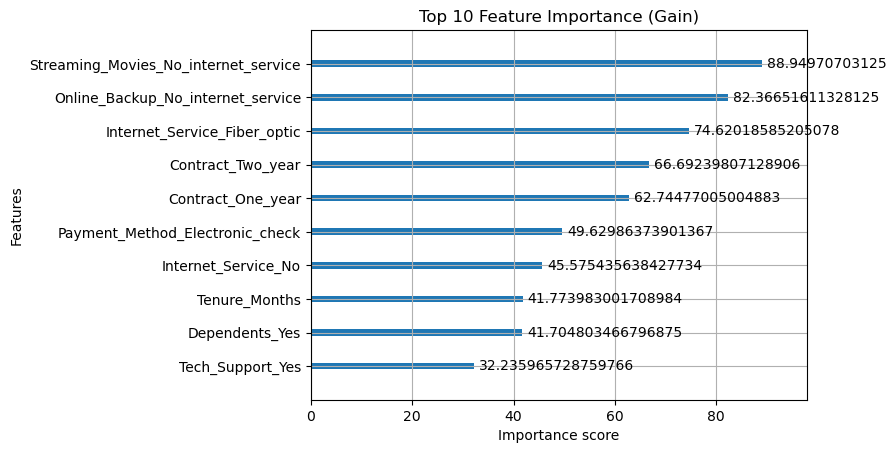

Feature importance (gain):
Streaming_Movies_No_internet_service: 88.94970703125
Online_Backup_No_internet_service: 82.36651611328125
Internet_Service_Fiber_optic: 74.62018585205078
Contract_Two_year: 66.69239807128906
Contract_One_year: 62.74477005004883
Payment_Method_Electronic_check: 49.62986373901367
Internet_Service_No: 45.575435638427734
Tenure_Months: 41.773983001708984
Dependents_Yes: 41.704803466796875
Tech_Support_Yes: 32.235965728759766
Device_Protection_No_internet_service: 23.143512725830078
Online_Security_Yes: 21.347721099853516
Online_Security_No_internet_service: 19.184301376342773
Monthly_Charges: 19.106082916259766
Paperless_Billing_Yes: 18.38541603088379
Total_Charges: 12.447226524353027
Streaming_Movies_Yes: 10.686379432678223
Multiple_Lines_No_phone_service: 10.513486862182617
Streaming_TV_Yes: 8.895430564880371
Online_Backup_Yes: 7.696281909942627
Multiple_Lines_Yes: 7.504563808441162
Senior_Citizen_Yes: 6.91619873046875
Zip_Code: 5.9345269203186035
Partner_Yes: 

In [35]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Plot top 10 features by gain
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importance (Gain)")
plt.show()
# Get booster
bst = best_model.get_booster()

# Feature importance by gain (how much each feature improves splits)
importance = bst.get_score(importance_type='gain')
importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))

print("Feature importance (gain):")
for feature, score in importance.items():
    print(f"{feature}: {score}")



/opt/anaconda3/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


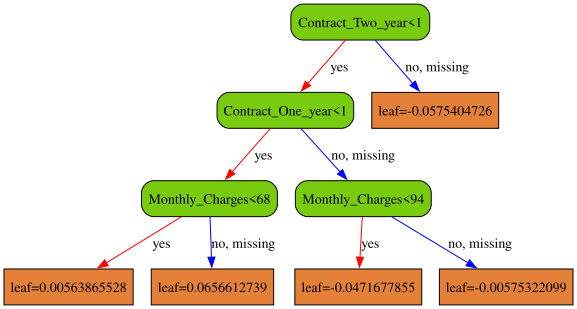

In [36]:
import xgboost as xgb
from IPython.display import Image
# Node/leaf styling
node_params = {'shape': 'box', 'style': 'filled, rounded', 'fillcolor': '#78cbe'}
leaf_params = {'shape': 'box', 'style': 'filled', 'fillcolor': '#e48038'}

graph = xgb.to_graphviz(
    best_model,
    num_trees=0,  # first tree
    condition_node_params=node_params,
    leaf_node_params=leaf_params
)
graph